# KMeans Clustering

In [ ]:
import pandas as pd
df = pd.read_csv("music_data.csv")

In [ ]:
df.head()

,track_artist,track_album_id,track_album_name,playlist_name,playlist_id,playlist_subgenre,danceability,energy,key,loudness,...,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,track_popularity,release_year,genre
0,Dead Prez,7gXuElmegVReY7imkb5bf8,Let's Get Free,90s Hiphop / Gangsta Rap,5yGuoOwRQF3o8NVRRlvCj7,gangster rap,0.725,0.737,4,-7.453,...,0.00417,0.109,0.219,77.161,214067,2HoDr1yVksl19omOhc1zWy,Hip-Hop,57,2000,Hip-Hop
1,Naughty By Nature,4OEP9VlZWOCt1QcOzX0oXF,19 Naughty III,90's Hip Hop Ultimate Collection,4IG024zoaGMurhTFBkMAv9,southern hip hop,0.862,0.642,6,-13.652,...,0.00000,0.272,0.765,99.201,267267,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop
2,Naughty By Nature,6smksVgwxaPFGdSsIloCjo,Anthem Inc.,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,new jack swing,0.776,0.968,4,-4.250,...,0.00000,0.204,0.667,97.765,250173,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop
3,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,Dr. Q's Prescription Playlist💊,6jAPdgY9XmxC9cgkXAVmVv,post-teen pop,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop
4,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,90s-2000s Southern Hip Hop / Crunk,5wsWBmQgDtKa8CEg7wTEMi,southern hip hop,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop


In [ ]:
df.columns

Index(['track_artist', 'track_album_id', 'track_album_name', 'playlist_name',
       'playlist_id', 'playlist_subgenre', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'track_id', 'track_name',
       'track_popularity', 'release_year', 'genre'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6484 entries, 0 to 6483
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_artist       6484 non-null   object 
 1   track_album_id     6484 non-null   object 
 2   track_album_name   6484 non-null   object 
 3   playlist_name      6484 non-null   object 
 4   playlist_id        6484 non-null   object 
 5   playlist_subgenre  6484 non-null   object 
 6   danceability       6484 non-null   float64
 7   energy             6484 non-null   float64
 8   key                6484 non-null   int64  
 9   loudness           6484 non-null   float64
 10  mode               6484 non-null   int64  
 11  speechiness        6484 non-null   float64
 12  acousticness       6484 non-null   float64
 13  instrumentalness   6484 non-null   float64
 14  liveness           6484 non-null   float64
 15  valence            6484 non-null   float64
 16  tempo              6484 

In [ ]:
# Remove duplicates
df = df.drop_duplicates()
df.size

149132

In [ ]:
df.isnull().sum()

,0
track_artist,0
track_album_id,0
track_album_name,0
playlist_name,0
playlist_id,0
playlist_subgenre,0
danceability,0
energy,0
key,0
loudness,0


In [ ]:
# Fill missing numeric values with median

df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity,release_year
count,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.00000,6484.000000,6484.000000
mean,0.656687,0.662695,5.108112,-6.339298,0.541487,0.116708,0.175291,0.028306,0.189283,0.461480,121.143942,225103.89343,60.130475,2013.432603
std,0.152863,0.175067,3.640679,2.571509,0.498314,0.108356,0.218181,0.122330,0.146737,0.220573,28.065763,54901.41406,18.761127,13.324169
min,0.135000,0.045500,0.000000,-23.459000,0.000000,0.023200,0.000015,0.000000,0.009360,0.034900,48.718000,37640.00000,0.000000,1958.000000
25%,0.555000,0.538000,1.000000,-7.621000,0.000000,0.043800,0.018900,0.000000,0.096900,0.293000,99.252000,191661.00000,53.000000,2012.000000
50%,0.671000,0.672000,5.000000,-5.884000,1.000000,0.065300,0.080450,0.000002,0.130000,0.440000,120.073000,216245.00000,63.000000,2018.000000
75%,0.771000,0.799000,8.000000,-4.559000,1.000000,0.153000,0.243000,0.000287,0.237000,0.619000,136.245000,248403.25000,72.000000,2022.000000
max,0.977000,0.998000,11.000000,-0.475000,1.000000,0.918000,0.984000,0.963000,0.984000,0.979000,207.969000,517125.00000,100.000000,2025.000000


In [ ]:
kmeans_df = df[['release_year', 'genre', 'track_popularity']]

kmeans_df.head(10)

,release_year,genre,track_popularity
0,2000,Hip-Hop,57
1,1993,Hip-Hop,66
2,1993,Hip-Hop,66
3,2007,Hip-Hop,35
4,2007,Hip-Hop,35
5,2007,Hip-Hop,35
6,2013,Hip-Hop,27
7,2013,Hip-Hop,27
8,2013,Hip-Hop,27
9,2007,Hip-Hop,48


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = kmeans_df.select_dtypes(include=['object']).columns

# Create a LabelEncoder instance
le = LabelEncoder()

# Convert each object column to numeric using Label Encoding
for column in categorical_cols:
    kmeans_df[column] = le.fit_transform(kmeans_df[column])

<ipython-input-13-60dd92c52b0a>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kmeans_df[column] = le.fit_transform(kmeans_df[column])


In [ ]:
kmeans_df.head(10)

,release_year,genre,track_popularity
0,2000,12,57
1,1993,12,66
2,1993,12,66
3,2007,12,35
4,2007,12,35
5,2007,12,35
6,2013,12,27
7,2013,12,27
8,2013,12,27
9,2007,12,48


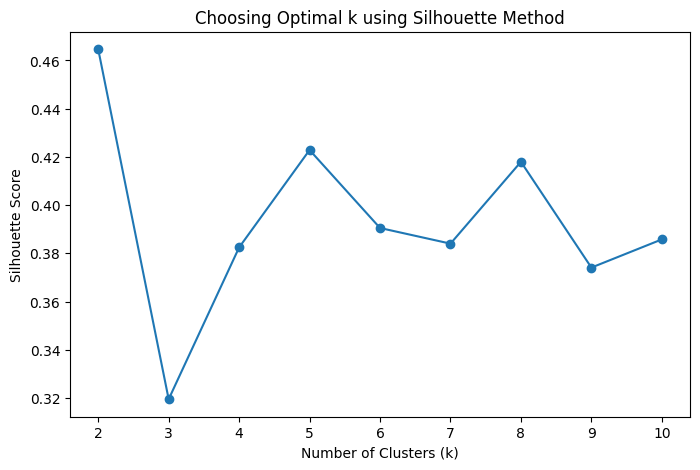

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Try different k values
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(kmeans_df)
    score = silhouette_score(kmeans_df, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Choosing Optimal k using Silhouette Method")
plt.show()


In [ ]:
range_n_clusters = range(2, 11)
silhouette_scores = {}

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(kmeans_df)
    score = silhouette_score(kmeans_df, cluster_labels)
    silhouette_scores[k] = score
    print(f"Silhouette score for k={k}: {score:.4f}")

# Choose three k-values with the highest silhouette scores
top_k = sorted(silhouette_scores, key=silhouette_scores.get, reverse=True)[:3]
print("Chosen k values for KMeans clustering:", top_k)


Silhouette score for k=2: 0.4647
Silhouette score for k=3: 0.3195
Silhouette score for k=4: 0.3824
Silhouette score for k=5: 0.4228
Silhouette score for k=6: 0.3905
Silhouette score for k=7: 0.3840
Silhouette score for k=8: 0.4180
Silhouette score for k=9: 0.3741
Silhouette score for k=10: 0.3858
Chosen k values for KMeans clustering: [2, 5, 8]


In [ ]:
from sklearn.cluster import KMeans
clustering = KMeans(n_clusters=2) # Assigning Random Number to cluster
kmeans_cluster = clustering.fit(kmeans_df)
kmeans_cluster

KMeans(n_clusters=2)

In [ ]:
df['Cluster'] = kmeans_cluster.labels_
df.head()

,track_artist,track_album_id,track_album_name,playlist_name,playlist_id,playlist_subgenre,danceability,energy,key,loudness,...,liveness,valence,tempo,duration_ms,track_id,track_name,track_popularity,release_year,genre,Cluster
0,Dead Prez,7gXuElmegVReY7imkb5bf8,Let's Get Free,90s Hiphop / Gangsta Rap,5yGuoOwRQF3o8NVRRlvCj7,gangster rap,0.725,0.737,4,-7.453,...,0.109,0.219,77.161,214067,2HoDr1yVksl19omOhc1zWy,Hip-Hop,57,2000,Hip-Hop,1
1,Naughty By Nature,4OEP9VlZWOCt1QcOzX0oXF,19 Naughty III,90's Hip Hop Ultimate Collection,4IG024zoaGMurhTFBkMAv9,southern hip hop,0.862,0.642,6,-13.652,...,0.272,0.765,99.201,267267,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop,1
2,Naughty By Nature,6smksVgwxaPFGdSsIloCjo,Anthem Inc.,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,new jack swing,0.776,0.968,4,-4.250,...,0.204,0.667,97.765,250173,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop,1
3,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,Dr. Q's Prescription Playlist💊,6jAPdgY9XmxC9cgkXAVmVv,post-teen pop,0.788,0.798,8,-4.680,...,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop,0
4,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,90s-2000s Southern Hip Hop / Crunk,5wsWBmQgDtKa8CEg7wTEMi,southern hip hop,0.788,0.798,8,-4.680,...,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop,0


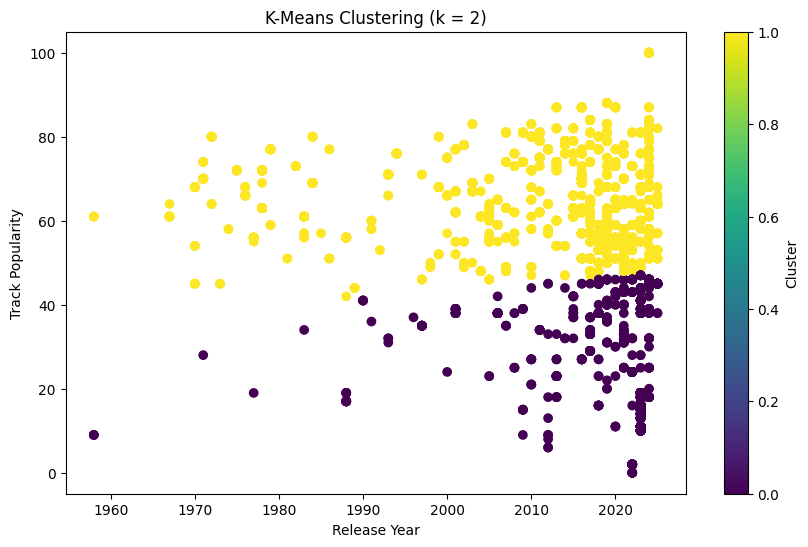

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['release_year'], df['track_popularity'], c=df['Cluster'], cmap='viridis')

plt.xlabel('Release Year')
plt.ylabel('Track Popularity')
plt.title('K-Means Clustering (k = 2)')
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
clustering = KMeans(n_clusters=5) # Assigning Random Number to cluster
kmeans_cluster = clustering.fit(kmeans_df)
kmeans_cluster

KMeans(n_clusters=5)

In [ ]:
df['Cluster'] = kmeans_cluster.labels_
df.head()

,track_artist,track_album_id,track_album_name,playlist_name,playlist_id,playlist_subgenre,danceability,energy,key,loudness,...,liveness,valence,tempo,duration_ms,track_id,track_name,track_popularity,release_year,genre,Cluster
0,Dead Prez,7gXuElmegVReY7imkb5bf8,Let's Get Free,90s Hiphop / Gangsta Rap,5yGuoOwRQF3o8NVRRlvCj7,gangster rap,0.725,0.737,4,-7.453,...,0.109,0.219,77.161,214067,2HoDr1yVksl19omOhc1zWy,Hip-Hop,57,2000,Hip-Hop,2
1,Naughty By Nature,4OEP9VlZWOCt1QcOzX0oXF,19 Naughty III,90's Hip Hop Ultimate Collection,4IG024zoaGMurhTFBkMAv9,southern hip hop,0.862,0.642,6,-13.652,...,0.272,0.765,99.201,267267,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop,0
2,Naughty By Nature,6smksVgwxaPFGdSsIloCjo,Anthem Inc.,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,new jack swing,0.776,0.968,4,-4.250,...,0.204,0.667,97.765,250173,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop,0
3,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,Dr. Q's Prescription Playlist💊,6jAPdgY9XmxC9cgkXAVmVv,post-teen pop,0.788,0.798,8,-4.680,...,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop,2
4,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,90s-2000s Southern Hip Hop / Crunk,5wsWBmQgDtKa8CEg7wTEMi,southern hip hop,0.788,0.798,8,-4.680,...,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop,2


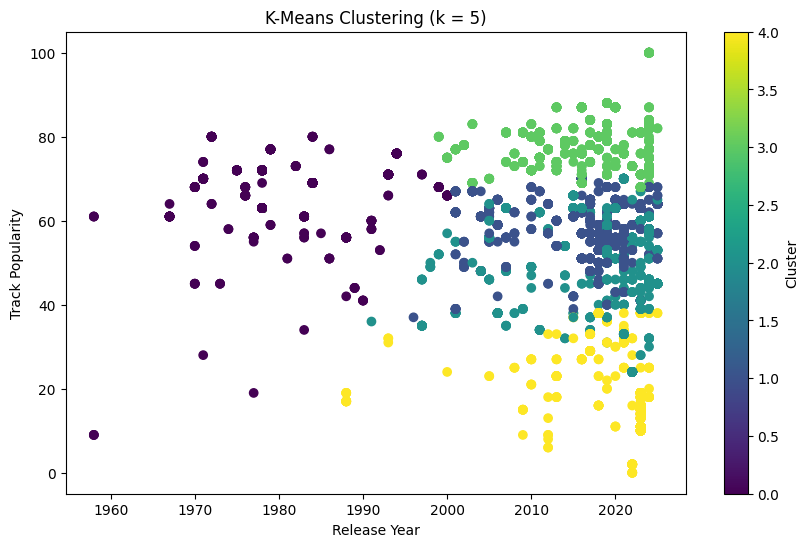

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['release_year'], df['track_popularity'], c=df['Cluster'], cmap='viridis')

plt.xlabel('Release Year')
plt.ylabel('Track Popularity')
plt.title('K-Means Clustering (k = 5)')
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
clustering = KMeans(n_clusters=8) # Assigning Random Number to cluster
kmeans_cluster = clustering.fit(kmeans_df)
kmeans_cluster

KMeans()

In [ ]:
df['Cluster'] = kmeans_cluster.labels_
df.head()

,track_artist,track_album_id,track_album_name,playlist_name,playlist_id,playlist_subgenre,danceability,energy,key,loudness,...,liveness,valence,tempo,duration_ms,track_id,track_name,track_popularity,release_year,genre,Cluster
0,Dead Prez,7gXuElmegVReY7imkb5bf8,Let's Get Free,90s Hiphop / Gangsta Rap,5yGuoOwRQF3o8NVRRlvCj7,gangster rap,0.725,0.737,4,-7.453,...,0.109,0.219,77.161,214067,2HoDr1yVksl19omOhc1zWy,Hip-Hop,57,2000,Hip-Hop,0
1,Naughty By Nature,4OEP9VlZWOCt1QcOzX0oXF,19 Naughty III,90's Hip Hop Ultimate Collection,4IG024zoaGMurhTFBkMAv9,southern hip hop,0.862,0.642,6,-13.652,...,0.272,0.765,99.201,267267,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop,0
2,Naughty By Nature,6smksVgwxaPFGdSsIloCjo,Anthem Inc.,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,new jack swing,0.776,0.968,4,-4.250,...,0.204,0.667,97.765,250173,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop,0
3,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,Dr. Q's Prescription Playlist💊,6jAPdgY9XmxC9cgkXAVmVv,post-teen pop,0.788,0.798,8,-4.680,...,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop,4
4,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,90s-2000s Southern Hip Hop / Crunk,5wsWBmQgDtKa8CEg7wTEMi,southern hip hop,0.788,0.798,8,-4.680,...,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop,4


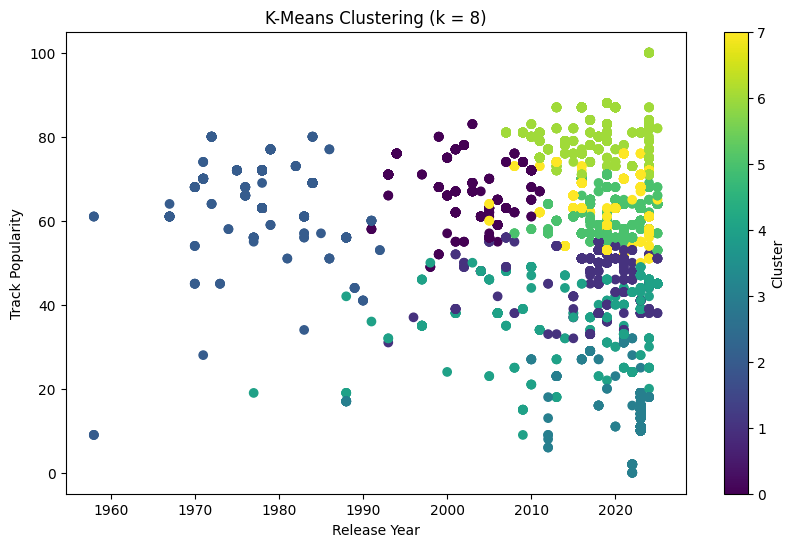

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['release_year'], df['track_popularity'], c=df['Cluster'], cmap='viridis')

plt.xlabel('Release Year')
plt.ylabel('Track Popularity')
plt.title('K-Means Clustering (k = 8)')
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')
plt.show()

# Hierarchical Clustering

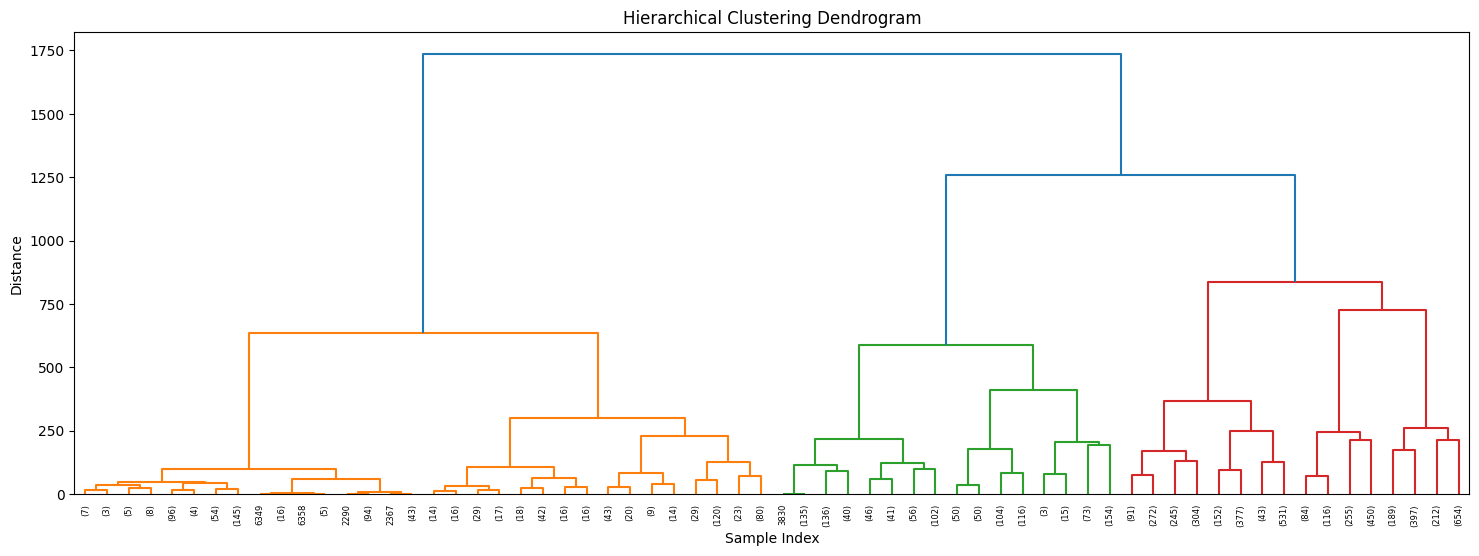

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(kmeans_df, method='ward')
plt.figure(figsize=(18, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

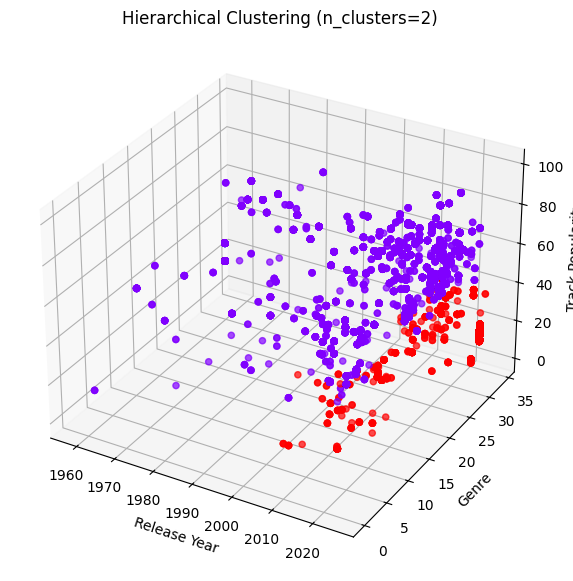

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# Choose optimal clusters from dendrogram
h_clusters = 2
hierarchical = AgglomerativeClustering(n_clusters=h_clusters)
labels_hierarchical = hierarchical.fit_predict(kmeans_df)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(kmeans_df.iloc[:, 0], kmeans_df.iloc[:, 1], kmeans_df.iloc[:, 2],
           c=labels_hierarchical, cmap="rainbow", alpha=0.7)

ax.set_xlabel("Release Year")
ax.set_ylabel("Genre")
ax.set_zlabel("Track Popularity")
ax.set_title(f"Hierarchical Clustering (n_clusters={h_clusters})")

plt.show()


# DBSCAN Clustering

DBSCAN cluster labels: [ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232
 233 234 235 236 237 238]


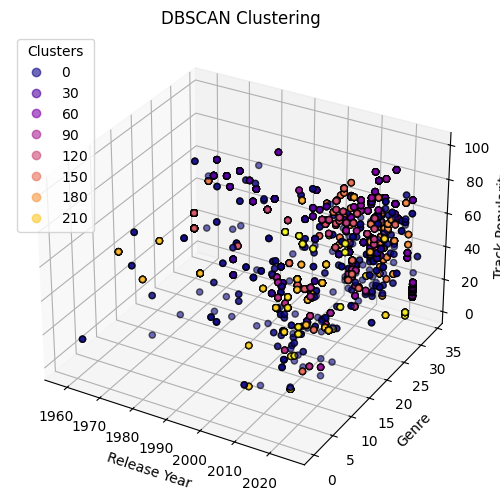

In [ ]:
# --- DBSCAN Clustering ---
from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(kmeans_df)
print("DBSCAN cluster labels:", np.unique(dbscan_labels))

# Visualize DBSCAN results
fig = plt.figure(figsize=(30,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(kmeans_df.iloc[:, 0], kmeans_df.iloc[:, 1], kmeans_df.iloc[:, 2],
                     c=dbscan_labels, cmap='plasma', alpha=0.6, edgecolor='k')
ax.set_title("DBSCAN Clustering")
ax.set_xlabel("Release Year")
ax.set_ylabel("Genre")
ax.set_zlabel("Track Popularity")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()
